# Hull–White Swaption Calibration and Parameter Identification

This notebook calibrates the one-factor Hull–White model to European USD SOFR OIS swaptions reported through the CFTC SDR on **2 September 2026**.

The analysis uses the SOFR discount curve constructed and frozen in the preceding curve-construction notebook. The main steps are:

- construct a defensible near-ATM swaption calibration basket from the cleaned CFTC data;
- validate the analytic Hull–White swaption pricer;
- calibrate the Hull–White parameters $a$ and $\sigma_{\mathrm{HW}}$ using relative premium errors;
- examine whether the calibration uniquely identifies the model parameters;
- repeat the identification analysis using Black implied-volatility residuals to test whether the result is driven by the calibration objective.

The resulting parameter-identification diagnostics will subsequently be propagated through the CCR exposure model.

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

from scipy.optimize import least_squares

from ccr_validation.curves import DiscountCurve
from ccr_validation.hull_white import HullWhite1F
from ccr_validation.swaps import fixed_leg_schedule, swap_annuity, forward_ois_rate
from ccr_validation.swaptions import hw_swaption_price
from ccr_validation.calibration import (
    add_market_black_vols,
    fit_hull_white_black_vol,
    fit_sigma_for_fixed_a,
    hw_implied_black_vol,
    price_calibration_row,
    relative_premium_residuals,
)

import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

plt.style.use("bmh")

plt.rcParams.update({
    "figure.figsize": (9, 5),
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
    "text.usetex": True,
    "font.size": 12,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
})

## 1. Market date and inputs

The valuation date is **2 September 2026**.

Two processed inputs are used:

1. the frozen USD SOFR OIS discount curve from the preceding curve-construction notebook;
2. the cleaned set of same-day CFTC USD SOFR European swaptions.

The discount curve is treated as fixed throughout the calibration analysis. The purpose of this notebook is therefore to study swaption calibration and Hull–White parameter identification, rather than curve-construction uncertainty.

In [2]:
market_date = pd.Timestamp("2026-09-02")

processed_path = Path("../data/processed")

curve_path = processed_path / "sofr_ois_pchip_curve_2026-09-02.csv"
swaptions_path = processed_path / "cftc_clean_swaptions_2026-09-02.csv"

ois = pd.read_csv(curve_path)
swaptions = pd.read_csv(swaptions_path)

curve = DiscountCurve(
    times=ois["time"],
    discount_factors=ois["discount_factor"],
)

## 2. Swaption data and contract interpretation

For the retained observations, the reported First exercise date equals the Expiration Date and is interpreted as option expiry $T_{\mathrm{exp}}$. The underlier maturity is $T_n$.

The implementation assumes the underlying swap starts at expiry, $T_0=T_{\mathrm{exp}}$, and uses a physically settled European payoff. The reported option dates do not establish these underlying contract conventions; their financial impact has not been quantified.

The `payer` flag distinguishes pay-fixed/receive-floating options from receive-fixed/pay-floating options. Market premiums are divided by notional $\mathcal{N}$, so the calibration compares prices per unit notional $v$. Currency prices are $V=\mathcal{N}v$.

In [3]:
date_cols = [
    "First exercise date",
    "Expiration Date",
    "Maturity date of the underlier",
]

for col in date_cols:
    swaptions[col] = pd.to_datetime(swaptions[col])

n_mismatch = (swaptions["First exercise date"] != swaptions["Expiration Date"]).sum()

print("First exercise date != expiration date:", n_mismatch)

First exercise date != expiration date: 0


In [4]:
swaptions[
    [
        "First exercise date",
        "Expiration Date",
        "Maturity date of the underlier",
        "option_expiry_years",
        "underlying_tenor_years",
        "strike",
        "payer",
        "premium_per_notional",
    ]
].head()

,First exercise date,Expiration Date,Maturity date of the underlier,option_expiry_years,underlying_tenor_years,strike,payer,premium_per_notional
0,2026-09-25,2026-09-25,2033-09-29,0.063014,7.016438,0.043375,False,0.00470
1,2026-09-25,2026-09-25,2033-09-29,0.063014,7.016438,0.043290,True,0.00465
2,2026-09-25,2026-09-25,2033-09-29,0.063014,7.016438,0.043290,False,0.00465
3,2026-09-25,2026-09-25,2033-09-29,0.063014,7.016438,0.043375,True,0.00470
4,2026-09-25,2026-09-25,2033-09-29,0.063014,7.016438,0.043290,True,0.00465


## 3. Forward swap rates and moneyness

Each underlying OIS is valued against the frozen SOFR curve. With fixed-leg payment dates $T_i$ and ACT/360 accrual fractions $\alpha_i$, its annuity and forward par rate today are

$$
A_{0,n}(0)=\sum_{i=1}^{n}\alpha_iP(0,T_i),\qquad
S_{0,n}(0)=\frac{P(0,T_0)-P(0,T_n)}{A_{0,n}(0)}.
$$

Moneyness compares the reported strike $K$ with that par rate:

$$m_{\mathrm{bp}}=10^4[K-S_{0,n}(0)].$$

Values close to zero are near ATM; positive values mean the strike is above the forward rate. The computed par rate is stored in `forward_rate`.

In [5]:
swaptions["forward_rate"] = swaptions.apply(
    lambda row: forward_ois_rate(
        curve=curve,
        market_date=market_date,
        start_date=row["First exercise date"],
        maturity_date=row["Maturity date of the underlier"],
    ),
    axis=1,
)

swaptions["moneyness_bp"] = 1e4 * (swaptions["strike"] - swaptions["forward_rate"])

## 4. Calibration basket construction

The paired reports retained in this basket were checked for economic equivalence during project development as previously reviewed. They are treated as linked reports rather than independently weighted payer and receiver prices. That prior check is distinct from the automated field checks below.

The selection first groups expiry, underlier maturity and strike, removes exact same-side duplicates, collapses near-ATM paired groups to a payer representative, excludes off-ATM paired groups, and retains the closest-to-ATM record per expiry/underlier maturity. All five final observations originate from paired groups.

The audit records original dissemination IDs, execution times, notionals and premium per notional. Before exporting or calibrating the basket, the code checks that its premiums per notional agree within a stated numerical tolerance. Different notionals or timestamps are recorded rather than treated as automatic failures. These checks preserve the verified per-unit economics; they do not independently determine settlement style or turn reported transactions into bid/ask quotes.

The near-ATM rule $|m_{\mathrm{bp}}|\le5$ is a selection convention, not evidence of liquidity or a statistical calibration acceptance threshold. The exported basket preserves its selected source ID and all associated group IDs.

In [6]:
# Remove exact same-side duplicates.
dedup_cols = [
    "Execution Timestamp",
    "First exercise date",
    "Maturity date of the underlier",
    "strike",
    "payer",
    "premium",
    "notional",
]

swpt = (
    swaptions
    .drop_duplicates(subset=dedup_cols)
    .copy()
    .reset_index(drop=True)
)

# Identify payer/receiver pairs for the same contract.
pair_key = [
    "First exercise date",
    "Maturity date of the underlier",
    "strike",
]

pair_info = (
    swpt.groupby(pair_key)
    .agg(
        n_payer=("payer", "sum"),
        n_receiver=("payer", lambda x: (~x).sum()),
        moneyness_bp=("moneyness_bp", "first"),
    ).reset_index()
)

pair_info["is_pair"] = ((pair_info["n_payer"] > 0) & (pair_info["n_receiver"] > 0))

pair_info["near_atm_pair"] = (pair_info["is_pair"] & (pair_info["moneyness_bp"].abs() <= 5.0))

pair_info["exclude_pair"] = (pair_info["is_pair"] & (pair_info["moneyness_bp"].abs() > 5.0))

swpt = swpt.merge(
    pair_info[pair_key + ["is_pair", "near_atm_pair", "exclude_pair"]],
    on=pair_key,
    how="left",
)

# Remove ambiguous off-ATM pairs.
baseline_candidates = swpt[~swpt["exclude_pair"]].copy()

# Collapse near-ATM payer/receiver pairs.
paired_near_atm = (
    baseline_candidates[baseline_candidates["near_atm_pair"]]
    .sort_values(pair_key + ["payer"], ascending=[True, True, True, False])
    .drop_duplicates(
        subset=pair_key,
        keep="first",
    )
    .copy()
)

paired_near_atm["paired_collapsed"] = True

unpaired = baseline_candidates[~baseline_candidates["is_pair"]].copy()

unpaired["paired_collapsed"] = False

baseline = pd.concat([unpaired, paired_near_atm], ignore_index=True)

baseline["abs_moneyness_bp"] = baseline["moneyness_bp"].abs()

# Retain near-ATM observations and one quote per expiry/maturity.
calibration_basket = (
    baseline[baseline["abs_moneyness_bp"] <= 5.0]
    .sort_values("abs_moneyness_bp")
    .drop_duplicates(
        subset=["First exercise date", "Maturity date of the underlier"],
        keep="first",
    )
    .sort_values(["option_expiry_years", "underlying_tenor_years"])
    .reset_index(drop=True)
)

# Preserve the previously checked per-unit economics and source traceability.
pair_audit_rows = []

for key_values, group in swpt.groupby(pair_key):

    has_both_sides = group["payer"].nunique() == 2

    premiums = group["premium_per_notional"].to_numpy(dtype=float)

    equivalent_unit_premiums = bool(np.allclose(premiums, premiums[0], rtol=1e-5, atol=1e-10))

    near_atm = bool(abs(group["moneyness_bp"].iloc[0]) <= 5.0)

    if has_both_sides and near_atm and not equivalent_unit_premiums:
        raise ValueError(f"Recheck paired premium interpretation: {key_values}")

    pair_audit_rows.append({
        **dict(zip(pair_key, key_values)),
        "is_pair": has_both_sides,
        "near_atm": near_atm,
        "equivalent_unit_premiums": equivalent_unit_premiums,
        "premium_per_notional_min": float(premiums.min()),
        "premium_per_notional_max": float(premiums.max()),
        "source_dissemination_identifiers": " | ".join(
            group["Dissemination Identifier"].astype(str).unique()
        ),
        "execution_timestamps": " | ".join(
            group["Execution Timestamp"].astype(str).unique()
        ),
        "reported_notionals": " | ".join(group["notional"].astype(str).unique()),
    })

pair_audit = pd.DataFrame(pair_audit_rows)

calibration_basket = calibration_basket.merge(
    pair_audit[pair_key + ["source_dissemination_identifiers"]],
    on=pair_key, how="left", validate="many_to_one",
)

calibration_basket["selection_reason"] = (
    "near-ATM representative; closest strike to model forward per expiry/maturity"
)

In [7]:
calibration_basket[
    [
        "option_expiry_years",
        "underlying_tenor_years",
        "payer",
        "strike",
        "forward_rate",
        "moneyness_bp",
        "premium_per_notional",
    ]
]

,option_expiry_years,underlying_tenor_years,payer,strike,forward_rate,moneyness_bp,premium_per_notional
0,0.063014,7.016438,True,0.043375,0.043340,0.350768,0.00470
1,0.082192,10.019178,True,0.044275,0.044236,0.394013,0.00675
2,1.000000,30.035616,True,0.045980,0.045971,0.091331,0.04930
3,2.010959,20.019178,True,0.046870,0.046949,-0.791069,0.05825
4,3.008219,10.010959,True,0.046200,0.046087,1.131790,0.04630


## 5. Hull–White swaption pricing and validation

Hull–White prices zero-coupon bonds as

$$
P(t,T)=\mathcal A(t,T)e^{-\mathcal B(t,T)r_t},
\qquad \mathcal B(t,T)=\frac{1-e^{-a(T-t)}}{a},
$$

$$
\mathcal A(t,T)=\frac{P(0,T)}{P(0,t)}
\exp\left[
\mathcal B(t,T)f(0,t)
-\frac{\sigma_{\mathrm{HW}}^2}{4a}(1-e^{-2at})\mathcal B(t,T)^2
\right].
$$

The coefficients reproduce the initial curve. Jamshidian decomposition then expresses a receiver swaption as a weighted portfolio of bond calls, and a payer swaption as bond puts. The implementation assumes $T_{\mathrm{exp}}=T_0$.

Before calibration, two pricing identities are checked. Prices per unit notional satisfy payer-receiver parity:

$$
v_{\mathrm{payer}}(0)-v_{\mathrm{receiver}}(0)
=A_{0,n}(0)[S_{0,n}(0)-K].
$$

As $\sigma_{\mathrm{HW}}\to0$, they converge to the positive and negative parts of the underlying forward-swap value per unit notional, $v_{\mathrm{swap}}(0)=A_{0,n}(0)[S_{0,n}(0)-K]$:

$$
v_{\mathrm{payer}}(0)\to[v_{\mathrm{swap}}(0)]^+,
\qquad
v_{\mathrm{receiver}}(0)\to[-v_{\mathrm{swap}}(0)]^+.
$$

The code checks both a near-zero volatility and the exact zero-volatility branch.

In [8]:
expiry_date = market_date + pd.DateOffset(years=1)
maturity_date = expiry_date + pd.DateOffset(years=10)

payment_dates, accruals = fixed_leg_schedule(expiry_date, maturity_date)

T_exp = (expiry_date - market_date).days / 365.0

payment_times = np.array([(d - market_date).days / 365.0 for d in payment_dates])

S_0n = forward_ois_rate(
    curve=curve,
    market_date=market_date,
    start_date=expiry_date,
    maturity_date=maturity_date,
)

A_0n = swap_annuity(
    curve=curve,
    market_date=market_date,
    start_date=expiry_date,
    maturity_date=maturity_date,
)

test_model = HullWhite1F(
    curve=curve,
    a=0.05,
    sigma=0.01,
)

K = S_0n + 0.0020  # 20 bp above ATM

payer_price = hw_swaption_price(
    test_model,
    T_exp,
    payment_times,
    accruals,
    K,
    True,
)

receiver_price = hw_swaption_price(
    test_model,
    T_exp,
    payment_times,
    accruals,
    K,
    False,
)

parity_rhs = A_0n * (S_0n - K)

parity_error = payer_price - receiver_price - parity_rhs

print(f"Put-call parity error: {parity_error:.3e}")

Put-call parity error: 9.557e-15


In [9]:
low_vol_model = HullWhite1F(
    curve=curve,
    a=0.05,
    sigma=1e-8,
)

df_start = curve.discount(T_exp)
df_end = curve.discount(payment_times[-1])

v_forward_swap = df_start - df_end - K * A_0n

payer_intrinsic = max(v_forward_swap, 0.0)
receiver_intrinsic = max(-v_forward_swap, 0.0)

payer_low_vol = hw_swaption_price(
    low_vol_model,
    T_exp,
    payment_times,
    accruals,
    K,
    True,
)

receiver_low_vol = hw_swaption_price(
    low_vol_model,
    T_exp,
    payment_times,
    accruals,
    K,
    False,
)

print(
    f"Payer:    model={payer_low_vol:.10f}, "
    f"intrinsic={payer_intrinsic:.10f}"
)

print(
    f"Receiver: model={receiver_low_vol:.10f}, "
    f"intrinsic={receiver_intrinsic:.10f}"
)

# Check the exact deterministic branch as well as the near-zero limit above.
zero_vol_model = HullWhite1F(curve=curve, a=0.05, sigma=0.0)

for payer_flag, intrinsic in [(True, payer_intrinsic), (False, receiver_intrinsic)]:

    zero_price = hw_swaption_price(
        zero_vol_model, T_exp, payment_times, accruals, K, payer_flag,
    )

    assert np.isclose(zero_price, intrinsic, atol=1e-10)
    
    print(f"Exact zero volatility, payer={payer_flag}: {zero_price:.10f}")

Payer:    model=0.0000000000, intrinsic=0.0000000000
Receiver: model=0.0154343693, intrinsic=0.0154343693
Exact zero volatility, payer=True: 0.0000000000
Exact zero volatility, payer=False: 0.0154343693


## 6. Baseline calibration using relative premium errors

The initial calibration minimises relative premium errors over the five instruments:

$$
\varepsilon_j^{\mathrm{rel}}(a,\sigma_{\mathrm{HW}})
=\frac{v_j^{\mathrm{HW}}(0;a,\sigma_{\mathrm{HW}})-v_j^{\mathrm{mkt}}}{v_j^{\mathrm{mkt}}},
\qquad
\min_{a,\sigma_{\mathrm{HW}}}\sum_j(\varepsilon_j^{\mathrm{rel}})^2.
$$

Relative errors prevent the largest premiums from dominating solely through their price scale. Optimisation uses $\log a$ and $\log\sigma_{\mathrm{HW}}$ to keep both parameters positive.

In [10]:
initial_guess = np.array([
    0.05,  # a
    0.01,  # sigma
])

fit = least_squares(
    relative_premium_residuals,
    x0=np.log(initial_guess),
    args=(
        curve,
        calibration_basket,
        market_date,
    ),
    xtol=1e-12,
    ftol=1e-12,
    gtol=1e-12,
    max_nfev=5000,
)

a_fit, sigma_fit = np.exp(fit.x)

residuals = relative_premium_residuals(
    fit.x,
    curve,
    calibration_basket,
    market_date,
)

rms_relative_error = np.sqrt(np.mean(residuals**2))

print(f"a: {a_fit:.8f}")
print(f"sigma_HW: {sigma_fit:.8f}")
print(f"RMS relative error: {100*rms_relative_error:.2f}%")

a: 0.00001652
sigma_HW: 0.00799610
RMS relative error: 8.30%


In [11]:
fitted_model = HullWhite1F(
    curve=curve,
    a=a_fit,
    sigma=sigma_fit,
)

calibration_result = calibration_basket.copy()

calibration_result["model_premium"] = (
    calibration_result.apply(
        lambda row: price_calibration_row(
            row=row,
            model=fitted_model,
            market_date=market_date,
        ),
        axis=1,
    )
)

calibration_result["relative_error_pct"] = (
    100 * (calibration_result["model_premium"] - calibration_result["premium_per_notional"])
    / calibration_result["premium_per_notional"]
)

calibration_result[
    [
        "option_expiry_years",
        "underlying_tenor_years",
        "premium_per_notional",
        "model_premium",
        "relative_error_pct",
    ]
]

,option_expiry_years,underlying_tenor_years,premium_per_notional,model_premium,relative_error_pct
0,0.063014,7.016438,0.00470,0.004838,2.926794
1,0.082192,10.019178,0.00675,0.007390,9.485341
2,1.000000,30.035616,0.04930,0.050911,3.267652
3,2.010959,20.019178,0.05825,0.055461,-4.788324
4,3.008219,10.010959,0.04630,0.039559,-14.559322


The calibration drives $a$ very close to zero while producing $\sigma_{\mathrm{HW}} \approx 0.008$.

The small fitted value of $a$ should not yet be interpreted as a precisely estimated mean-reversion parameter. The next section examines the calibration objective as a function of $a$ to determine whether the parameter is actually identified by the available swaption data.

## 7. Parameter identification under the relative-premium objective

A small fitted $a$ does not establish precise identification. Fixing $a$ on a grid and re-optimising $\sigma_{\mathrm{HW}}$ gives the profiled RMS error

$$
J_{\mathrm{rel}}(a)=\min_{\sigma_{\mathrm{HW}}>0}
\sqrt{\frac{1}{N_{\mathrm{cal}}}\sum_j(\varepsilon_j^{\mathrm{rel}})^2}.
$$

Here $N_{\mathrm{cal}}=5$ is the instrument count. A sharply defined minimum would distinguish values of $a$; a broad or flat region indicates weak identification.

In [12]:
a_grid = np.logspace(-5, 0, 80)

profile_rows = []

market_prices = (
    calibration_basket["premium_per_notional"]
    .to_numpy()
)

for a_fixed in a_grid:

    def sigma_residual(log_sigma):
        sigma = np.exp(log_sigma[0])

        model = HullWhite1F(
            curve=curve,
            a=a_fixed,
            sigma=sigma,
        )

        model_prices = calibration_basket.apply(
            lambda row: price_calibration_row(
                row=row,
                model=model,
                market_date=market_date,
            ),
            axis=1,
        ).to_numpy()

        return (model_prices - market_prices) / market_prices

    sigma_fit = least_squares(
        sigma_residual,
        x0=np.log([0.008]),
        xtol=1e-12,
        ftol=1e-12,
        gtol=1e-12,
    )

    sigma_best = np.exp(sigma_fit.x[0])

    rms_relative_error = np.sqrt(np.mean(sigma_residual(np.log([sigma_best])) ** 2))

    profile_rows.append({
        "a": a_fixed,
        "sigma": sigma_best,
        "rms_relative_error": rms_relative_error,
    })

profile = pd.DataFrame(profile_rows)

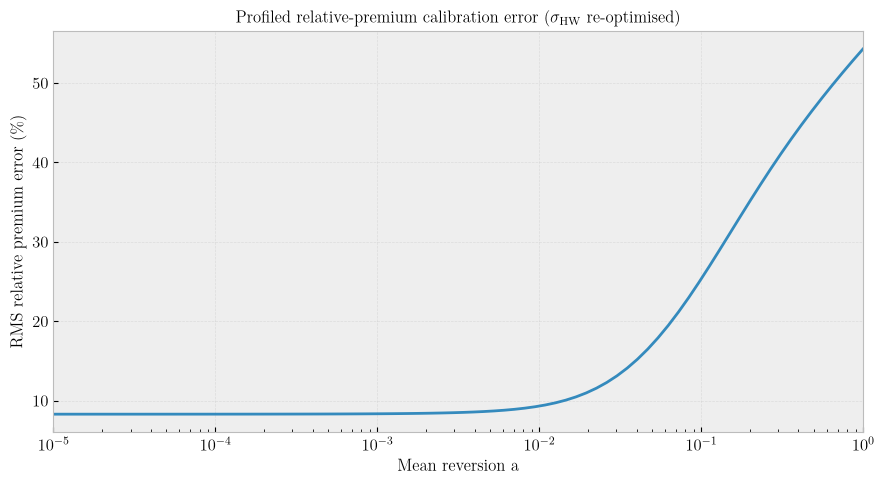

In [13]:
plt.semilogx(
    profile["a"],
    100 * profile["rms_relative_error"],
)

plt.xlim(1e-5, 1)

plt.xlabel("Mean reversion a")
plt.ylabel("RMS relative premium error (\\%)")
plt.title(r"Profiled relative-premium calibration error ($\sigma_{\mathrm{HW}}$ re-optimised)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

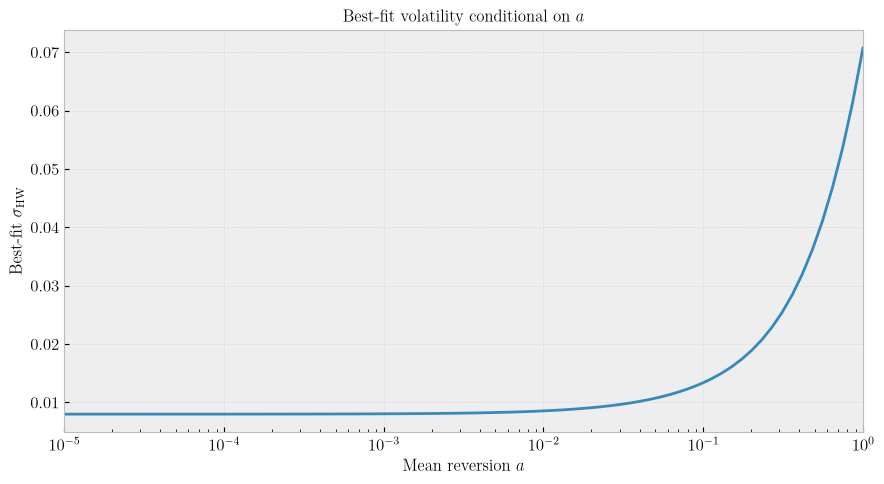

In [14]:
plt.semilogx(
    profile["a"],
    profile["sigma"],
)

plt.xlim(1e-5, 1)

plt.xlabel("Mean reversion $a$")
plt.ylabel(r"Best-fit $\sigma_{\mathrm{HW}}$")
plt.title("Best-fit volatility conditional on $a$")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

The profiled objective is essentially flat as $a$ approaches zero. Over this region, $\sigma_{\mathrm{HW}}$ remains close to $0.008$, while larger values of $a$ require progressively larger $\sigma_{\mathrm{HW}}$ to compensate for stronger mean reversion.

The calibration therefore exhibits a low-$a$ valley rather than a sharply defined optimum in $a$. This indicates that the available swaption basket weakly identifies the mean-reversion parameter under the relative-premium objective.

However, this does not yet establish whether the weak identification is caused by the information content of the swaption data or by the particular weighting induced by relative premium errors. The next section repeats the analysis using a materially different calibration objective.

## 8. Objective-function robustness using Black implied volatilities

Relative premium errors weight observations according to their price scale. To check whether the low-$a$ valley depends on this choice, the calibration is repeated in Black implied-volatility space.

For each instrument, Black-76 inversion converts the market and Hull–White premiums into $\sigma_{\mathrm{Black},j}^{\mathrm{mkt}}$ and $\sigma_{\mathrm{Black},j}^{\mathrm{HW}}$. Their difference is the alternative residual:

$$
\varepsilon_j^{\mathrm{vol}}
=\sigma_{\mathrm{Black},j}^{\mathrm{HW}}-\sigma_{\mathrm{Black},j}^{\mathrm{mkt}}.
$$

These are annualised Black implied volatilities; $\sigma_{\mathrm{HW}}$ remains the short-rate volatility parameter.

In [15]:
calibration_basket = add_market_black_vols(
    calibration_basket=calibration_basket,
    curve=curve,
    market_date=market_date,
)

In [16]:
a_vol_fit, sigma_vol_fit, rms_vol_error = fit_hull_white_black_vol(
    curve=curve,
    calibration_basket=calibration_basket,
    market_date=market_date,
    initial_guess=(0.05, 0.01),
)

print(f"a: {a_vol_fit:.8f}")
print(f"sigma_HW: {sigma_vol_fit:.8f}")
print(f"RMS Black vol error: {100 * rms_vol_error:.2f} percentage points"
)

a: 0.00000505
sigma_HW: 0.00809564
RMS Black vol error: 1.60 percentage points


## 9. Parameter identification under the Black-vol objective

The Black-vol calibration also returns a very small fitted $a$. Fixing $a$ and re-optimising $\sigma_{\mathrm{HW}}$ gives

$$
J_{\mathrm{vol}}(a)=\min_{\sigma_{\mathrm{HW}}>0}
\sqrt{\frac{1}{N_{\mathrm{cal}}}\sum_j(\varepsilon_j^{\mathrm{vol}})^2}.
$$

If relative-premium weighting were the main cause of weak identification, a substantially different profile would be expected here.

In [17]:
# a_grid = np.logspace(-5, 0, 80)

profile_rows = []

for a_fixed in a_grid:

    sigma_best, rms_vol_error = fit_sigma_for_fixed_a(
        a=a_fixed,
        curve=curve,
        calibration_basket=calibration_basket,
        market_date=market_date,
        initial_sigma=0.008,
        sigma_bounds=(1e-5, 0.2),
    )

    profile_rows.append({
        "a": a_fixed,
        "sigma": sigma_best,
        "rms_vol_error": rms_vol_error,
    })

vol_profile = pd.DataFrame(profile_rows)

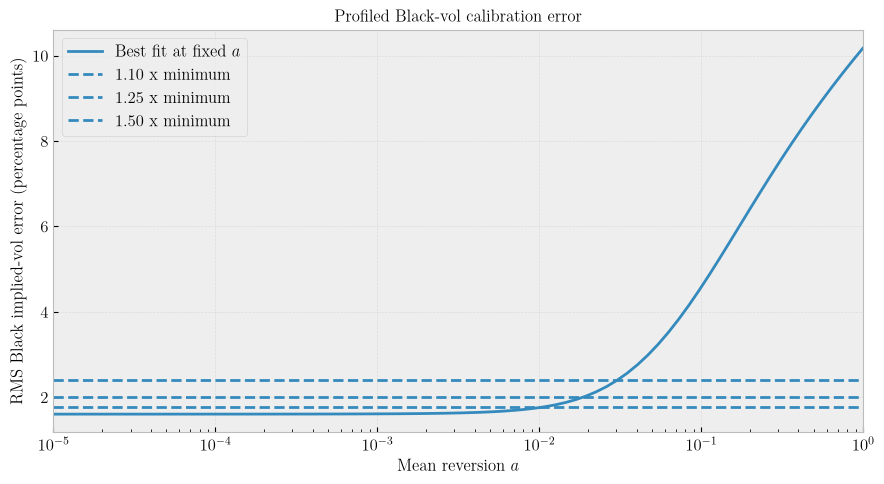

In [18]:
J_min = vol_profile["rms_vol_error"].min()

plt.semilogx(
    vol_profile["a"],
    100 * vol_profile["rms_vol_error"],
    label="Best fit at fixed $a$",
)

for multiplier in [1.10, 1.25, 1.50]:
    plt.axhline(
        100 * multiplier * J_min,
        linestyle="--",
        label=f"{multiplier:.2f} x minimum",
    )

plt.xlim(1e-5, 1)

plt.xlabel("Mean reversion $a$")
plt.ylabel("RMS Black implied-vol error (percentage points)")
plt.title("Profiled Black-vol calibration error")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
for multiplier in [1.10, 1.25, 1.50]:

    illustrative_region = vol_profile[vol_profile["rms_vol_error"] <= multiplier * J_min]

    print(
        f"{multiplier:.2f} x minimum: "
        f"a <= {illustrative_region['a'].max():.5f}"
    )

1.10 x minimum: a <= 0.00943
1.25 x minimum: a <= 0.01690
1.50 x minimum: a <= 0.03027


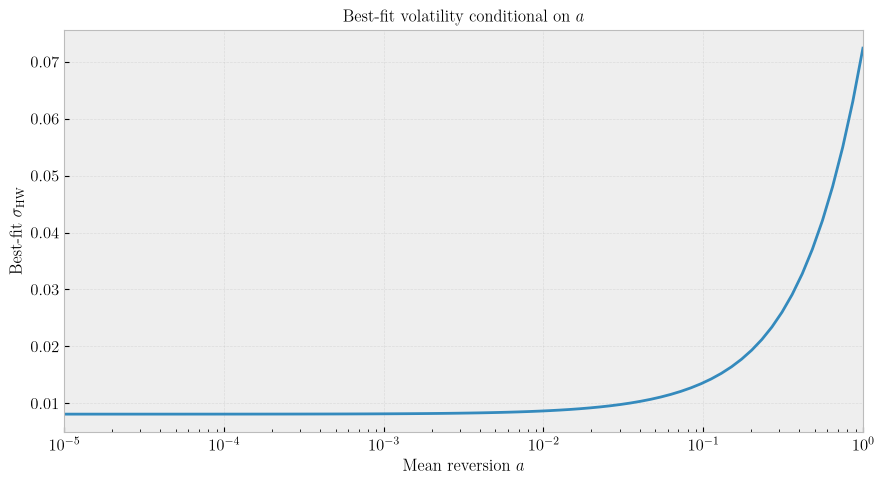

In [20]:
plt.semilogx(
    vol_profile["a"],
    vol_profile["sigma"],
)

plt.xlim(1e-5, 1)

plt.xlabel("Mean reversion $a$")
plt.ylabel(r"Best-fit $\sigma_{\mathrm{HW}}$")
plt.title("Best-fit volatility conditional on $a$")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
market_vols = calibration_basket["market_black_vol"].to_numpy()

a_values = np.logspace(
    -5,
    0,
    80,
)

sigma_values = np.linspace(
    0.005,
    0.0125,
    80,
)

vol_objective_surface = np.empty((len(a_values), len(sigma_values)))

for i, a in enumerate(a_values):
    for j, sigma in enumerate(sigma_values):

        model = HullWhite1F(
            curve=curve,
            a=a,
            sigma=sigma,
        )

        try:
            model_vols = calibration_basket.apply(
                lambda row: hw_implied_black_vol(
                    row=row,
                    model=model,
                    market_date=market_date,
                ),
                axis=1,
            ).to_numpy()

            vol_objective_surface[i, j] = (np.sqrt(np.mean((model_vols - market_vols) ** 2)))
        except ValueError:
            vol_objective_surface[i, j] = np.nan

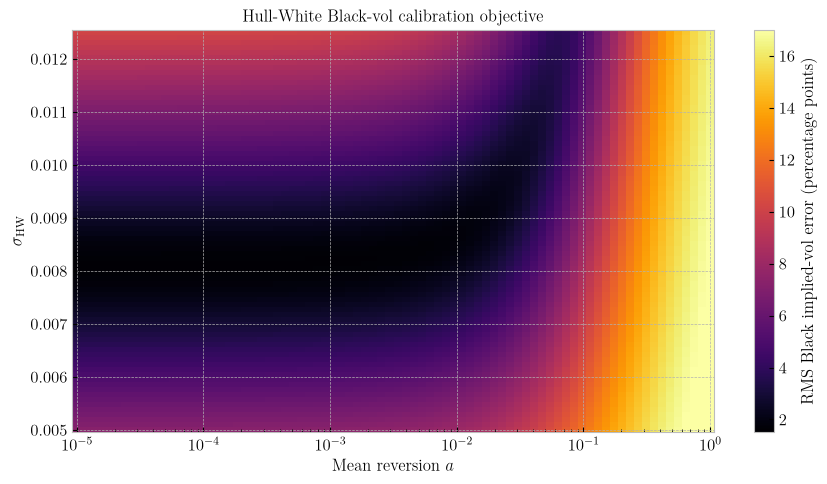

In [22]:
a_mesh, sigma_hw_mesh = np.meshgrid(
    a_values,
    sigma_values,
    indexing="ij",
)

pcm = plt.pcolormesh(
    a_mesh,
    sigma_hw_mesh,
    100 * vol_objective_surface,
    cmap='inferno',
    vmin=1.5,
    vmax=17,
)

plt.xscale("log")

plt.xlabel("Mean reversion $a$")
plt.ylabel(r"$\sigma_{\mathrm{HW}}$")
plt.title("Hull-White Black-vol calibration objective")

plt.colorbar(
    pcm,
    label="RMS Black implied-vol error (percentage points)",
)

figures_path = Path("../results/figures")
calibration_path = figures_path / "calibration_profile.png"
plt.savefig(calibration_path, dpi=200, bbox_inches="tight")

plt.tight_layout()
plt.show()

The Black-vol objective displays a relatively flat low-$a$ profile, followed by a compensating increase in fitted $\sigma_{\mathrm{HW}}$ as $a$ increases.

This qualitative behaviour persists after changing the calibration objective. It therefore is not specific to relative-premium weighting. The profile alone does not establish whether sparse market coverage, constant-volatility HW1F misspecification or other input assumptions are the main cause.

Within this basket and model specification, the data constrain the volatility scale more strongly than mean-reversion speed. No statistical parameter interval or market-fit acceptance region has been established.

## 10. Optimiser robustness and conclusion

The identification analysis above relies on repeatedly minimising the calibration objective over $\sigma_{\mathrm{HW}}$ at fixed $a$.

As a final numerical check, the Black-vol objective is evaluated directly over a dense grid of $\sigma_{\mathrm{HW}}$ values at

$$
a = 10^{-5}.
$$

The grid minimum is compared with the result returned by the least-squares optimiser. This checks that the low-$a$ calibration valley is not an artefact of failure in the inner optimisation over $\sigma_{\mathrm{HW}}$.

In [23]:
a_test = 1e-5

market_vols = calibration_basket["market_black_vol"].to_numpy()

sigma_grid = np.logspace(
    np.log10(0.001),
    np.log10(0.10),
    300,
)

rms_grid = []

for sigma in sigma_grid:

    model = HullWhite1F(
        curve=curve,
        a=a_test,
        sigma=sigma,
    )

    try:
        model_vols = calibration_basket.apply(
            lambda row: hw_implied_black_vol(
                row=row,
                model=model,
                market_date=market_date,
            ),
            axis=1,
        ).to_numpy()

        rms = np.sqrt(np.mean((model_vols - market_vols) ** 2))

    except ValueError:
        rms = np.nan

    rms_grid.append(rms)

rms_grid = np.asarray(rms_grid)

i_best = np.nanargmin(rms_grid)

sigma_grid_best = sigma_grid[i_best]
rms_grid_best = rms_grid[i_best]

In [24]:
sigma_lsq, rms_lsq = fit_sigma_for_fixed_a(
    a=a_test,
    curve=curve,
    calibration_basket=calibration_basket,
    market_date=market_date,
    initial_sigma=0.008,
    sigma_bounds=(1e-5, 0.2),
)

print(
    f"Grid:          sigma_HW={sigma_grid_best:.8f}, "
    f"RMS={100 * rms_grid_best:.6f} pp"
)

print(
    f"Least squares: sigma_HW={sigma_lsq:.8f}, "
    f"RMS={100 * rms_lsq:.6f} pp"
)

Grid:          sigma_HW=0.00812267, RMS=1.603406 pp
Least squares: sigma_HW=0.00809592, RMS=1.602255 pp


In [25]:
results_path = Path("../results")
results_path.mkdir(parents=True, exist_ok=True)

calibration_export_cols = [
    "Dissemination Identifier",
    "Execution Timestamp",
    "source_dissemination_identifiers",
    "selection_reason",
    "paired_collapsed",
    "First exercise date",
    "Maturity date of the underlier",
    "option_expiry_years",
    "underlying_tenor_years",
    "strike",
    "payer",
    "premium_per_notional",
    "forward_rate",
    "moneyness_bp",
    "annuity",
    "market_black_vol",
]

calibration_basket[calibration_export_cols].to_csv(
    results_path / "hw_swaption_calibration_basket_2026-09-02.csv",
    index=False,
)

pair_audit.to_csv(results_path / "swaption_pair_audit_2026-09-02.csv", index=False)

## Conclusion

Both objectives favour very low positive mean reversion, with a relatively flat profile near the boundary. This supports weak identification in this basket/model specification; it does not uniquely establish whether limited data coverage, constant-volatility HW1F misspecification or other input assumptions explain the profile.

The minimum Black-vol RMS is about 1.6 volatility percentage points. Neither bid/ask uncertainty nor a market-fit acceptance threshold has been established. The illustrative RMS multipliers are not confidence bounds or approval criteria. The subsequent study therefore uses **selected profiled parameter scenarios**, not equally acceptable alternative market fits.

The unit-premium audit and source IDs preserve the paired-record checks performed during development. Contract settlement/start-date simplifications remain explicit limitations. The implementation checks support the assumed European payoff, including its exact zero-volatility limit; they do not establish production pricing or model approval.